# Practica: Redes convolucionales

In [1]:
#%connect_info
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as cm
import time
import copy
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import torchvision.transforms as transforms

from torchvision.datasets import CIFAR10
from torchvision.datasets import MNIST

ModuleNotFoundError: No module named 'torchvision'

In [2]:
def contarCorrectas(net,batch,labels,func=None):
    '''Dado un batch y sus etiquetas, cuenta el numero de respuestas
    correctas de una red, el parametro func aplica una modificacion al 
    tensor que contiene los datos'''
    
    if(func!=None):
        batch=func(batch)
        salidas=net(batch)
    else:
        salidas=net(batch)
    respuestas=salidas.max(dim=1)[1]
    cantidadCorrectas=(respuestas==labels).sum()
    return cantidadCorrectas
    
def calcularPrecisionGlobal(net,data_loader,batch_size,func=None,cuda=False):
    '''Calcula la precision de una red dado un data_loader,
    recive una funcion que transforma los datos en caso de ser necesario'''
    correctas=0
    for (images,labels) in data_loader:
        if(cuda and torch.cuda.is_available()):
            images=images.cuda()
            labels=labels.cuda()
        correctas+=contarCorrectas(net,images,labels,func)        
    correctas=correctas.data.tolist()
    return (100*correctas)/(len(data_loader)*batch_size) 

# Cifar 10
Es un conjunto de datos que tiene 60,000 imagenes de 32x32 a color de 10 clases distintas (cada clase con 6,000 elementos).
Las clases de este conjunto de datos corresponden a:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, y truck.

Podemos descargar CIFAR-10 con el modulo de torchvision.

In [3]:
#Cargamos los datos de este conjunto en las variables correspondientes al igual que el caso de MNIST
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transforms.ToTensor())
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transforms.ToTensor())

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


Para resolver el problema de clasificación de las imágenes de CIFAR-10 usaremos una red neuronal 
cuya arquitectura sea la siguiente:

* Una capa convolucional de entrada con un filtro de (5,5) y 64 filtros de salida con activación ReLu
* Una capa de MaxPooling de (3,3)
* Otra capa convolucional con un filtro de (5,5) y 32 filtros de salida con activación ReLu
* Una capa de MaxPooling de (3,3)
* Una capa completamente conectada con 384 neuronas,cuya activacion es ReLu
* Una capa completamente conectada con 192 neuronas,cuya activacion es ReLu
* Finalmente,una capa de salida con 10 neuronas



In [4]:
#airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.
import torch.nn.functional as F
class CIFAR_NET(nn.Module):
    def __init__(self):
        '''
        Construcción de la Red, define las capas que se utiizaran.
        '''
        super(CIFAR_NET, self).__init__()
        #Toma en cuenta el constructor de las capas convolucionales
        self.features = nn.Sequential(
            # Primer capa convolucional, el conjunto de datos consta de imagenes a color RGB.
            ## Por lo que tendrá 3 entradas y 64 filtros de salida.
            nn.Conv2d(3, 64, 5),
            # Usamos como función de activación la rectificadora lineal.
            nn.ReLU(),
            # Reducimos nuestros datos con la función de pooling, en este caso 
            # usando el promedio para crear la nueva matriz. Usamos un stride de 2.
            nn.AvgPool2d(2, stride=2),
        )
        self.features1 = nn.Sequential(
            # Construimos la segunda capa con 64 entradas y 32 salidas. 
            nn.Conv2d(64, 32, 5),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            ## Realizamos el max pooling con un stride de 3.
            nn.AvgPool2d(3, stride=3)
        )
        self.classifier = nn.Sequential(
            # Por ultimo usaremos dos capas completamente conectadas, esperando 
            # que pueda obtener suficientes datos a partir de las convoluciones 
            # que hemos realizado.
            nn.Linear(288, 384),
            nn.ReLU(),
            nn.Linear(384,192),
            nn.ReLU(),
            nn.Linear(192, 10)
        )

    def forward(self, x):
        '''
        Define el orden con el que se realizará la propagación hacia adelante
        de la red.
        '''
        x = self.features(x)
        x = self.features1(x)
        # Aquí es necesario aplanar los resultados para que puedan aplicarse a 
        # las capas lineales.
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
    def train_cnn(self,model,epochs,data_loader,criterion,optimizer,cuda=False):
        '''
        Define una función de entrenamiento, ten en cuenta la forma en la que llegan 
        los datos de data_loader, e itera sobre ellos. Realiza también el caso 
        en que se llegue a utilizar cuda. Muestra una gráfica al finalizar el
        entrenamiento usando el lost obtenido.
        '''
        best_model_wts = copy.deepcopy(model.state_dict())
        best_acc = 0.0
        ind = 0
        for epoch in range(epochs):
            print('Epoch {}/{}'.format(epoch, epochs - 1))
            print('----------')
            for phase in ['train', 'val']:
                if (phase == 'train'):
                    model.train()
                else:
                    model.eval()
                running_loss = 0.0
                running_corrects = 0
                for inputs, labels in data_loader[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs,labels)
                    _, preds = torch.max(outputs,1)
                    if(phase == 'train'):
                        loss.backward()
                        optimizer.step()
                    running_loss += loss.item()*inputs.size(0)
                    running_corrects += torch.sum(preds==labels.data)
                epoch_loss = running_loss / len(data_loader[phase])
                epoch_acc = running_corrects.double() / len(data_loader[phase])
                print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))
                if(phase == 'val' and epoch_acc > best_acc):
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                print('----------')
            plt.plot(ind, epoch_loss, 'o--', color = 'blue')
            ind += 1
        plt.show()
        print('Best val Acc: {:4f}'.format(best_acc))
        model.load_state_dict(best_model_wts)
        return model

In [5]:
## Conjunto que constará de los datos de entrenamiento y de validación.
datas = [x for x in trainloader]

In [6]:
# Definimos los conjuntos de entrenamiento y validación a paritr de los datos cargados.
train_rate = 0.8
size = len(datas)
size = int(np.ceil(size*train_rate))
train_dic = {'train':datas[:size] , 'val':datas[size:]}
print(len(train_dic['train']))
print(len(train_dic['val']))

RedCIFAR=CIFAR_NET()
params_to_update = RedCIFAR.parameters()
optimizer = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

## Usaremos entropía cruzada como función de pérdida.
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = RedCIFAR.to(device)

10000
2500


C:\Users\HP\anaconda3\lib\site-packages\torch\cuda\__init__.py:52: UserWarning: CUDA initialization: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx (Triggered internally at  ..\c10\cuda\CUDAFunctions.cpp:100.)
  return torch._C._cuda_getDeviceCount() > 0


In [7]:
# Si tenemos un modelo anterior, lo cargamos.

try:
    std_dict = torch.load('./CIFAR.pth')
    model.load_state_dict(std_dict)
    print("Modelo cargado.")
except:
    print("Modelo nuevo.")
    

Modelo cargado.


Epoch 0/5
----------
train Loss: 2.8918 Acc: 3.0946
----------
val Loss: 2.1746 Acc: 3.2868
----------
Epoch 1/5
----------
train Loss: 1.6674 Acc: 3.4410
----------
val Loss: 2.1861 Acc: 3.3068
----------
Epoch 2/5
----------
train Loss: 1.0845 Acc: 3.6485
----------
val Loss: 2.3967 Acc: 3.2876
----------
Epoch 3/5
----------
train Loss: 0.7435 Acc: 3.7635
----------
val Loss: 2.7662 Acc: 3.2572
----------
Epoch 4/5
----------
train Loss: 0.5515 Acc: 3.8206
----------
val Loss: 3.1193 Acc: 3.2028
----------
Epoch 5/5
----------
train Loss: 0.4994 Acc: 3.8333
----------
val Loss: 3.4840 Acc: 3.1848
----------


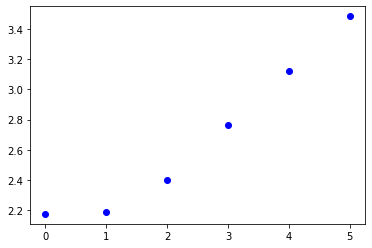

Best val Acc: 3.306800


In [8]:
#Define el criterio que usaras para evaluar a la red y un optimizador.
#Y define el preprosesamiento necesario en caso de requerir usar cuda.
#Entrenamos la red durante 50 pasos(o los que consideres necesarios),con entropia cruzada y el optimizador 
RedCIFAR = RedCIFAR.train_cnn(RedCIFAR, 6,train_dic,criterion,optimizer,cuda=False) #puedes agregar cuda=True si tienes GPU disponible
torch.save(model.state_dict(),"./CIFAR.pth")

In [12]:
## Calculamos la presición del modelo con los datos de prueba.
prec_val=calcularPrecisionGlobal(RedCIFAR,testloader,4)
print("Precision en conjunto de prueba: %.4f%%"%(prec_val))


Precision en conjunto de validacion: 69.3400%


In [13]:
## Calculamos la presición del modelo con los datos de entrenamiento.
prec_train =calcularPrecisionGlobal(RedCIFAR,trainloader,4)
print("Precision en conjunto de entrenamiento: %.4f%%"%(prec_train))

Precision en conjunto de entrenamiento: 88.4200%


## Ejercicios:
* Crea las funciones necesarias para poder introducir datos concretos a la red (una vez ya entrenada) y obtener el resultado que esta devuelve. Muestra la imagen con la que se está alimentando a la red.
* Con la red neuronal entrenada obten la matriz de confusion de ambos conjuntos (entrenamiento y prueba) con las 10 clases posibles. Para ello en lugar de tener en cuenta únicamente los valores de verdaderos positivos, verdaderos negativos, etc, se usarán los 10 elementos, por lo que debemos tener en cuenta cuantos de cada categoria fueron clasificados incorrectamente, y en cual fue.
* Despues de cada MaxPool normaliza las salidas y contrasta el rendimiento de la red.

In [8]:
# Veamos los filtros que está red ha aprendido.
model = RedCIFAR
capa1 = model.features[0].weight.detach()
capa2 = model.features1[0].weight.detach()


In [9]:
def imshow(img, title,cmap, norm=None):
    '''
    Función para mostrar las matrices.
    '''
    plt.figure()
    plt.axis('off')
    plt.imshow(img, norm=norm)
    plt.title(title)
    plt.show()
    
    
def imagenshow(img1, img2, img3, title, norm = None):
    'Función para mostrar las imágenes en RGB'
    ima = torch.zeros([32, 32, 3])
    for i in range(32):
        for j in range(32):
            ima[i][j] = torch.tensor([[img1[i][j], img2[i][j], img3[i][j]]])
    plt.figure()
    plt.axis('off')
    plt.imshow(ima, norm=norm)
    plt.title(title)
    plt.show()

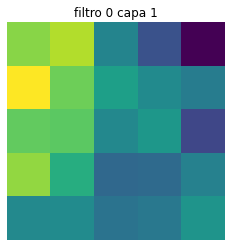

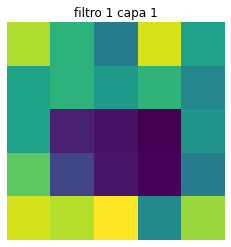

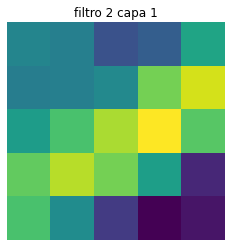

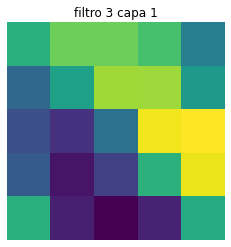

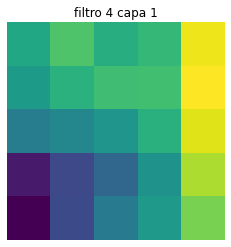

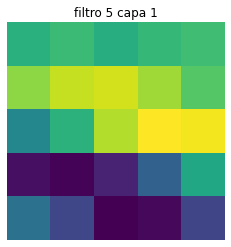

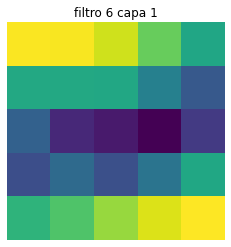

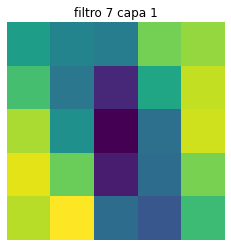

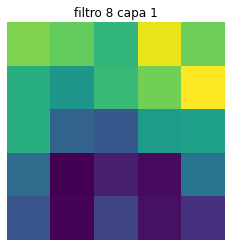

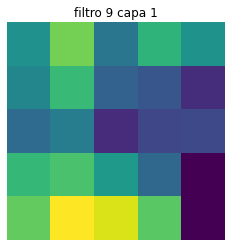

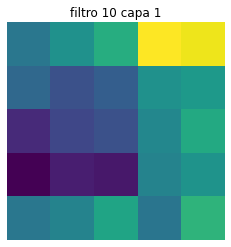

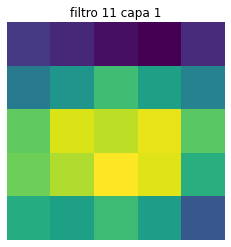

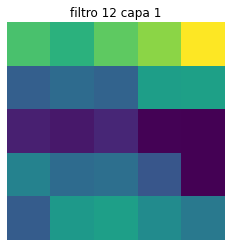

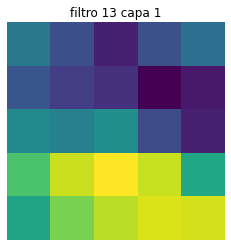

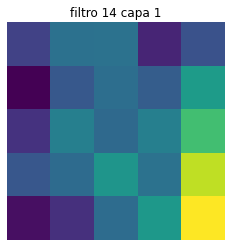

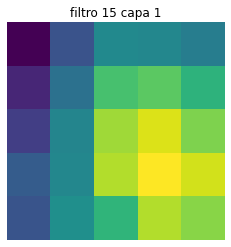

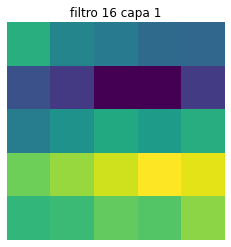

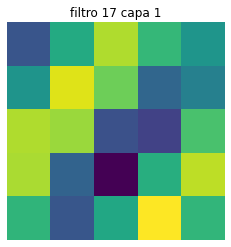

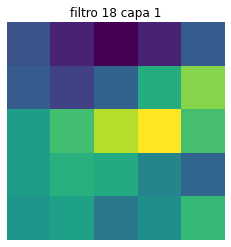

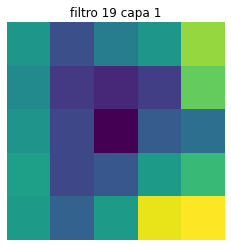

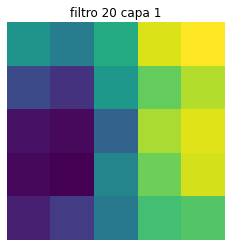

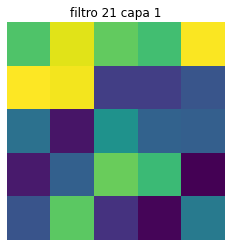

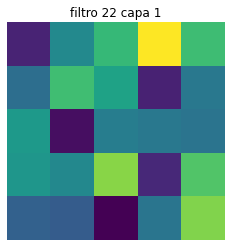

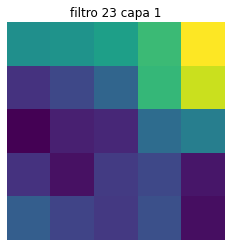

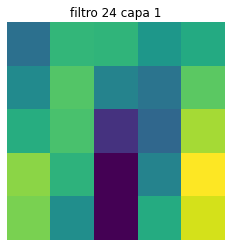

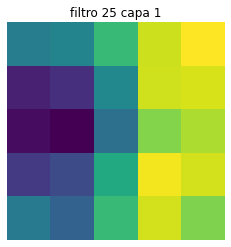

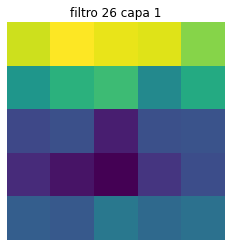

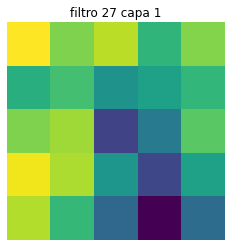

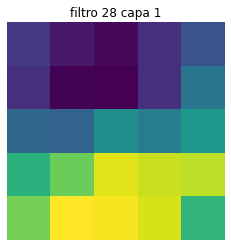

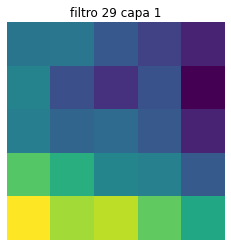

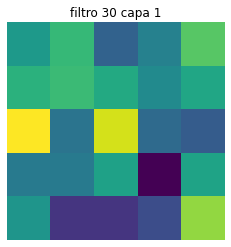

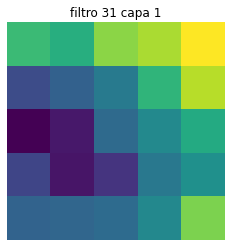

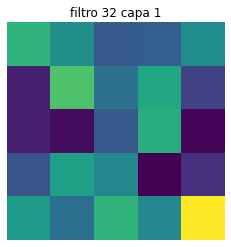

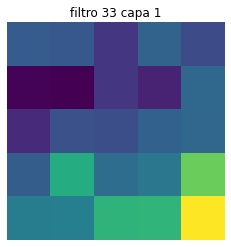

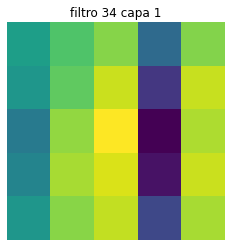

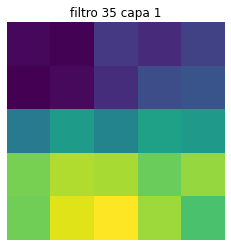

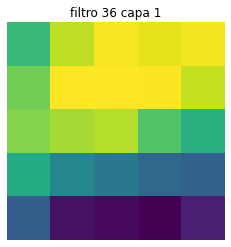

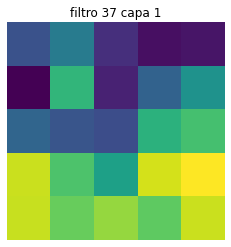

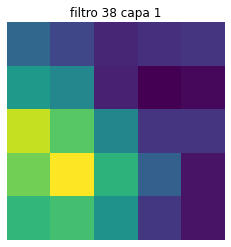

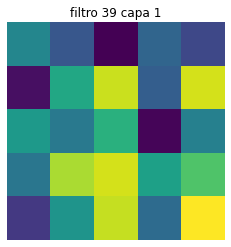

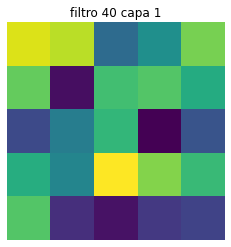

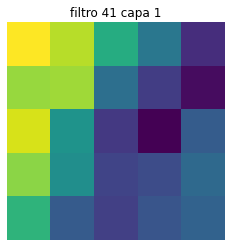

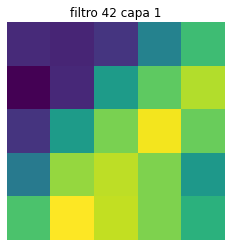

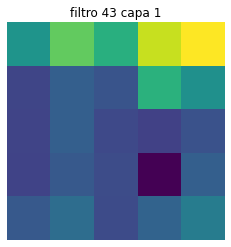

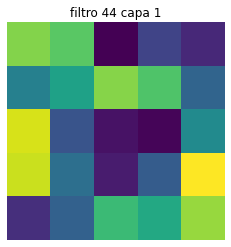

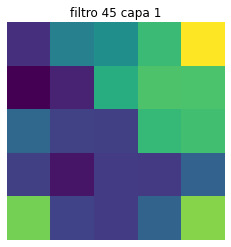

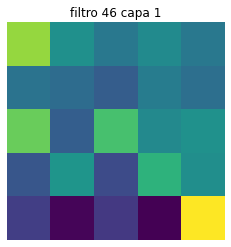

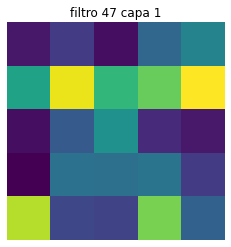

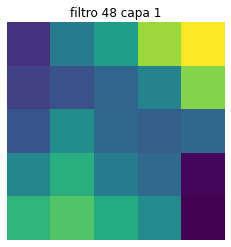

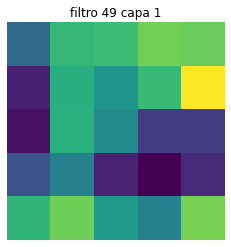

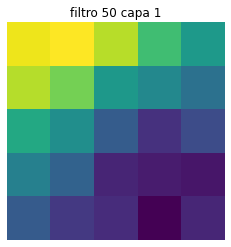

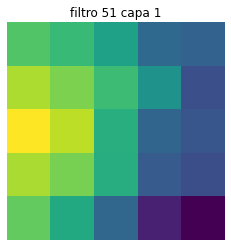

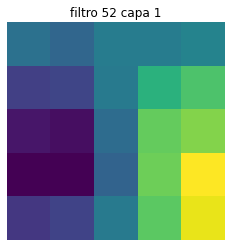

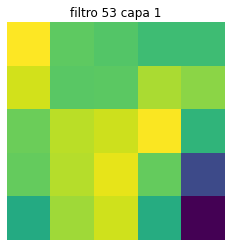

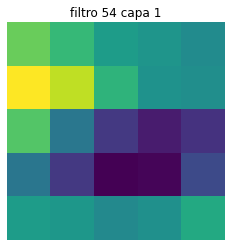

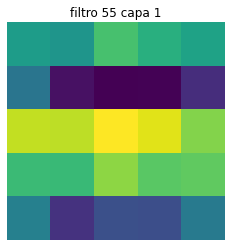

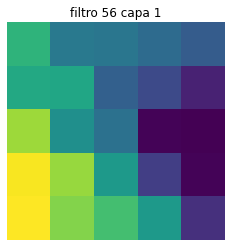

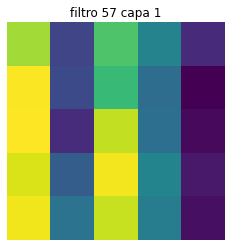

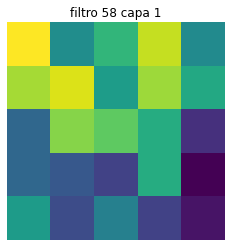

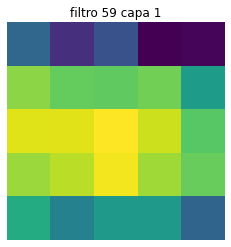

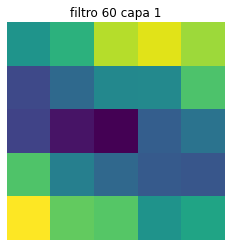

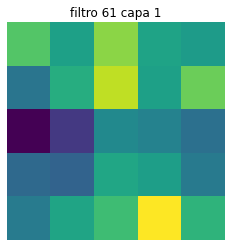

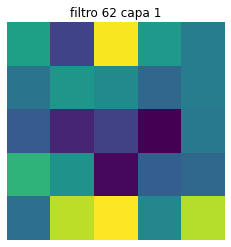

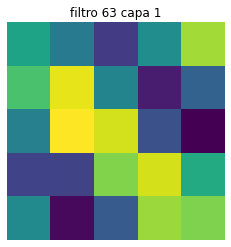

In [10]:
## Los 64 filtros obtenidos en la primera capa.
i = 0
for filtro in capa1:
    imshow(filtro[0,:,:],'filtro {} capa 1'.format(i),'winter')
    i+=1

In [11]:
## Para alimentar a la red ya entrenada de una nueva imágen usando los datos de prueba.
datos_test = [x for x in testloader]

El modelo considera que la imágen corresponde a un dog
La respuesto correcta es dog


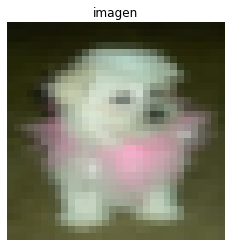

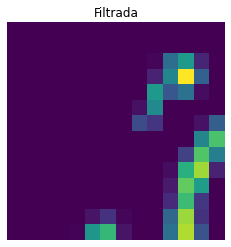

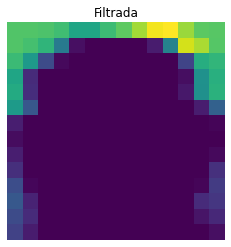

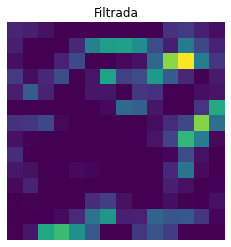

In [12]:
(imagen, label) = datos_test[750]
o = model(imagen)
_,pred = torch.max(o,1)
print('El modelo considera que la imágen corresponde a un', classes[int(pred[0])])
print('La respuesto correcta es', classes[label[0]])
imagenshow(imagen[0, 0, :, :], imagen[0, 1, :, :], imagen[0, 2, :, :], 'imagen')

procesada = model.features(imagen)
imshow(procesada[0,0,:,:].detach(),'Filtrada','winter')
imshow(procesada[0,1,:,:].detach(),'Filtrada','winter')
imshow(procesada[0,2,:,:].detach(),'Filtrada','winter')


In [13]:
## Matrices de confusión.
## Primero veamos una matriz de confusión que sólo considere falsos positivos, falsos negativos, verdaderos falsos 
## y verdaderos positivos.
## Puesto que tenemos 10 categorias, si el modelo acierta en un ejemplar, se agregará un verdadero positivo y se sumarán
## 9 verdaderos negativos. En caso contrario se sumará un falso positivo, un falso negativo y 8 verdaderos negativos.
def confusion1(model, data):
    confusion = np.array([[0, 0], [0, 0]])
    for i in range(len(data)):
        (imagen, label) = datos_test[i]
        o = model(imagen)
        _,pred = torch.max(o,1)
        ## Recordemos que tomamos un batch = 4
        for j in range(4):
            if int(pred[j]) == label[j]:
                confusion[0][0] += 1
                confusion[1][1] += 9 
            else:
                confusion[0][1] += 1
                confusion[1][0] += 1
                confusion[1][1] += 8
    return confusion

## Una segunda versión de la matriz de confusión con una matriz de 10 x 10 para tener una mejor idea de las predicciones
## que está haciendo nuestro modelo.
## Cada renglón representa la clase del ejemplar y cada columna representa la predicción del modelo.
## Con esto, la diagonal representa a las clases que fueron bien clasificadas por el modelo.
## Además calcula la precisión de cada clase.

def confusion(model, data):
    confusion = np.array([[0]*10]*10)
    acc = np.array([[0.0]]*10)
    for i in range(len(data)):
        (imagen, label) = datos_test[i]
        o = model(imagen)
        _,pred = torch.max(o,1)
        for j in range(4):
            confusion[label[j]][int(pred[j])] += 1
    for i in range(10):
        acc[i][0] = confusion[i][i]/sum(confusion[i])
    return confusion, 100*acc


In [14]:
print("La primer matriz de conufsión de nuesto modelo es:")
print(confusion1(model, datos_test))

La primer matriz de conufsión de nuesto modelo es:
[[ 6632  3368]
 [ 3368 86632]]


In [42]:
print("El segundo tipo de matriz de confusión obtenida es:")
matriz, accuracy = confusion(model, datos_test)
print(matriz)
print(accuracy)
print("El orden de las clases es: ", classes)

El segundo tipo de matriz de confusión obtenida es:
[[737   8  63  30  10   8  13  15  75  41]
 [ 15 777  20  18   4   9  15   6  45  91]
 [ 57   8 610  81  63  81  51  24  13  12]
 [ 24  10  93 530  46 174  55  28  20  20]
 [ 29   1 109  84 587  70  38  56  16  10]
 [ 10   2  59 174  44 633  32  28   7  11]
 [  6   3  70  81  25  36 749   5  10  15]
 [ 25   3  32  71  50  73   9 709   4  24]
 [ 60  26  27  22   7   8   8   4 794  44]
 [ 28  55  19  17   2  12   6  13  40 808]]
[[73.7]
 [77.7]
 [61. ]
 [53. ]
 [58.7]
 [63.3]
 [74.9]
 [70.9]
 [79.4]
 [80.8]]
El orden de las clases es:  ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


Referencias:

* Krizhevsky , Nair , Hinton. CIFAR-10. https://www.cs.toronto.edu/~kriz/cifar.html
* Pytorch, TORCH.NN, https://pytorch.org/docs/stable/nn.html
* Goodfellow-et-al. (2016). Deep Learning. MIT Press. https://www.deeplearningbook.org/contents/convnets.html

In [ ]:
from IPython.core.display import HTML
def css_styling():
    styles = open("styles/custom.css", "r").read() #or edit path to custom.css
    return HTML(styles)
css_styling()